# 제조 전력 예측 · 최적화 — 정리본

본 노트북은 소은이 만든 HGB 전력 예측 모델(`Best_Way.py`)을 불러온 뒤,
**4가지 최적화 시도**를 순서대로 정리한 것입니다.

1. 전력값 재분배 (총생산량 보존)
2. 생산량 재배치 (±20%, CP-SAT)
3. 매칭 최적화 (유사 사례 참조)
4. 안전마진 최적화 (Water-filling LP)

**결론 먼저**: 4가지 시도 중 수치로 명확한 개선을 보인 것은 **1. 전력값 재분배** 뿐이며,
나머지 3가지는 모두 '개선 여지 없음/재현 안 됨'으로 끝났습니다.
이는 실패가 아니라, **현재 데이터(생산량·기온·풍속·습도·강수량·시간변수)에 기록되지 않은 다른 요인**
(설비 운전방식, 중복가동 등)이 피크를 결정짓는다는 것을 실험적으로 보여준 결과로 해석합니다.


## 0. 모델 불러오기
팀원 소은이 만든 HGB(HistGradientBoosting) 전력 예측 모델을 실행합니다.
이 셀 하나로 데이터 전처리 → 학습 → 예측까지 전부 끝나며, 이후 모든 최적화는 이 결과(`prediction`, `test` 등)를 재사용합니다.

In [6]:
%run Best_Way.py


테스트 결과: {'MAE': 10.1623, 'RMSE': 14.5122, 'R2': 0.94}


In [7]:
# ===== Best_Way.py 실행 (팀원 소은의 모델) =====
%run Best_Way.py

# ===== 실제 존재하는 변수명으로 결과 확인 =====
print("원본 데이터:", len(raw), "행")
print("학습 데이터:", len(train), "행")
print("검증 데이터:", len(valid), "행")
print("테스트 데이터:", len(test), "행")

print("\n모델 예측 성능:")
print(f"MAE  : {test_metrics['MAE']:.4f}")
print(f"RMSE : {test_metrics['RMSE']:.4f}")
print(f"R²   : {test_metrics['R2']:.4f}")

print("\n예측값 미리보기 (15분/30분/45분/60분 뒤 전력):")
print(test_prediction.head())



테스트 결과: {'MAE': 10.1623, 'RMSE': 14.5122, 'R2': 0.94}
원본 데이터: 6168 행
학습 데이터: 4272 행
검증 데이터: 912 행
테스트 데이터: 936 행

모델 예측 성능:
MAE  : 10.1623
RMSE : 14.5122
R²   : 0.9400

예측값 미리보기 (15분/30분/45분/60분 뒤 전력):
                           15분        30분        45분        60분
timestamp                                                      
2021-08-07 00:00:00  44.777164  42.234151  34.085002  40.955224
2021-08-07 01:00:00  48.728198  50.938772  55.458189  54.548709
2021-08-07 02:00:00  41.547660  50.724674  54.083756  52.599765
2021-08-07 03:00:00  38.904364  50.370653  51.589304  50.559012
2021-08-07 04:00:00  34.351771  49.572450  52.185566  50.171096


In [8]:
# 최적화에서 쓸 1차원 예측 시퀀스 (15분 뒤 전력 기준)
prediction = test_prediction["15분"].values
actual_values = test["15분"].values

# 최적화용 데이터프레임 (test는 이미 DatetimeIndex + 전처리 완료 상태)
df_optimize = test.copy()
df_optimize["시간"] = df_optimize.index.hour

print(f"예측 데이터 길이: {len(prediction)}")
print(f"예측값 예시 (처음 5개): {prediction[:5]}")
print(f"습도 컬럼 존재 여부: {'습도' in df_optimize.columns}")

예측 데이터 길이: 936
예측값 예시 (처음 5개): [44.77716351 48.72819771 41.54766041 38.90436393 34.35177136]
습도 컬럼 존재 여부: True


## 0-1. 최적화용 데이터 준비
이후 1~2번(전력값 재분배, 생산량 재배치)에서 공통으로 쓸 `df_optimize`(예측값 + 생산량 + 날씨)를 구성합니다.


In [9]:
# ===== 최적화용 데이터 준비 =====
import numpy as np
import pandas as pd
from ortools.linear_solver import pywraplp

# test 데이터 기준으로 예측값 확보 (이미 test_prediction에 있음)
prediction = test_prediction["15분"].values   # 15분 뒤 전력 예측치 (1차원 배열)
actual_values = test["15분"].values            # 실제값

df_optimize = test.copy()
df_optimize["시간"] = df_optimize.index.hour
df_optimize["요일"] = df_optimize.index.dayofweek

print(f"예측 데이터 길이: {len(prediction)}")
print(f"예측값 예시(5개): {prediction[:5]}")
print(f"실제값 예시(5개): {actual_values[:5]}")
print(f"습도 컬럼 존재: {'습도' in df_optimize.columns}")
print(df_optimize[["생산량","기온","풍속","습도","강수량","15분"]].head())

예측 데이터 길이: 936
예측값 예시(5개): [44.77716351 48.72819771 41.54766041 38.90436393 34.35177136]
실제값 예시(5개): [21 25 21 21 21]
습도 컬럼 존재: True
                     생산량    기온   풍속  습도  강수량  15분
timestamp                                        
2021-08-07 00:00:00    0  26.2  1.0  91  0.0   21
2021-08-07 01:00:00    0  25.8  1.9  97  0.0   25
2021-08-07 02:00:00    0  25.9  2.5  98  0.0   21
2021-08-07 03:00:00    0  26.1  2.0  98  0.0   21
2021-08-07 04:00:00    0  25.9  0.5  98  0.0   21


## 1. 전력값 재분배 (총생산량 보존)
**아이디어**: 생산계획은 그대로 두고, 예측된 전력값 자체를 시간대 간에 옮겨서 피크만 낮춘다.
**제약**: 시간대별 안전상한(과거 데이터 평균+1.28*표준편차) + 전역 피크상한(98백분위) 을 넘지 않는 선에서 LP로 재분배.
**결과**: 피크 173.08 → 164.00 kW로 감소, 총생산량(총합)은 그대로 보존됨.
**한계**: 생산계획과 무관하게 전력값 자체만 재배열하는 것이라 현실 적용성은 낮음 — 하지만 4개 시도 중 유일하게 수치 개선이 뚜렷함.

In [10]:
# ===== 강건 최적화 - 목적: AI가 예측한 전력량에는 오차(MAE 10.16)가 있다. 
#그 오차를 고려해 안전 마진(Safety Margin)을 두고, 피크 전력을 절대 넘지 않도록 생산 스케줄을 평탄화
#Step 1: 시간대별 안전 마진 계산 =====

# 전체 데이터(df) 기준으로 시간대별 전력 통계 산출 (test가 아니라 df 전체 사용 -> 더 많은 과거 데이터 확보)
df["시간"] = df.index.hour

hourly_stats = df.groupby("시간")["15분"].agg(["mean", "std"]).fillna(0)
z_score = 1.28  # 90% 신뢰구간

hourly_stats["safety_bound"] = hourly_stats["mean"] + z_score * hourly_stats["std"]

print("시간대별 평균 / 표준편차 / 안전상한선:")
print(hourly_stats)

# 전역 계약 전력(피크 제한) - 데이터 전체 15분 전력의 최댓값 근처로 설정
global_peak_limit = df["15분"].quantile(0.98)  # 상위 2% 극단치는 제외한 현실적 피크
print(f"\n전역 피크 제한(98백분위): {global_peak_limit:.2f} kW")


시간대별 평균 / 표준편차 / 안전상한선:
          mean        std  safety_bound
시간                                     
0    54.568627  23.924796     85.192366
1    69.588235  33.934151    113.023949
2    79.670588  41.738515    133.095888
3    69.258824  34.291991    113.152572
4    78.760784  40.763984    130.938684
5    63.309804  30.597883    102.475094
6    80.615686  42.198366    134.629595
7    76.250980  39.681505    127.043306
8   111.827451  65.594027    195.787806
9   119.423529  72.619173    212.376071
10   97.890196  56.546926    170.270261
11  119.741176  71.648830    211.451678
12   82.019608  45.592551    140.378073
13  114.239216  67.936701    201.198193
14  118.062745  70.071870    207.754738
15   95.666667  54.059557    164.862900
16  112.874510  66.929566    198.544355
17   84.843137  46.402880    144.238824
18  109.717647  64.745768    192.592230
19  103.305882  61.179938    181.616203
20   81.878431  45.267761    139.821166
21   85.705882  46.900084    145.737990
22   71.772549  

In [11]:
# ===== 1. 전력값 재분배 - 총 생산량은 그대로 유지한 채 재분배(최대 피크 낮춤) =====
from ortools.linear_solver import pywraplp

def run_robust_optimization_v4(test_df, prediction, hourly_stats, strict_peak_limit):
    n = len(prediction)
    solver = pywraplp.Solver.CreateSolver('CBC')

    power = [solver.NumVar(0, 400, f'power_{t}') for t in range(n)]

    # 핵심 제약: 전체 총생산(총 전력량)은 반드시 보존되어야 함
    # → 한 시간을 깎으면, 반드시 다른 시간이 그만큼 늘어나야 함 (제로섬 트레이드오프)
    total_target = float(np.sum(prediction))
    solver.Add(solver.Sum(power) == total_target)

    for t in range(n):
        hour_of_day = test_df.index[t].hour
        safe_limit = min(strict_peak_limit, hourly_stats.loc[hour_of_day, "safety_bound"])
        solver.Add(power[t] <= safe_limit)   # 상한선은 반드시 지킴
        solver.Add(power[t] >= prediction[t] * 0.5)  # 너무 많이 깎이지 않도록 하한선도 설정

    # 목적함수: 원래 예측값과의 편차 최소화 (단, 총량 보존 제약 하에서)
    gap = [solver.NumVar(0, 400, f'gap_{t}') for t in range(n)]
    for t in range(n):
        solver.Add(gap[t] >= power[t] - prediction[t])
        solver.Add(gap[t] >= prediction[t] - power[t])
    solver.Minimize(solver.Sum(gap))

    status = solver.Solve()
    if status == pywraplp.Solver.OPTIMAL:
        schedule = [power[t].solution_value() for t in range(n)]
        return schedule, n
    else:
        print(f"솔버 상태 이상(Infeasible 가능): {status}")
        return None, n

strict_peak_limit = np.percentile(df["15분"], 90)
schedule_v4, n = run_robust_optimization_v4(test, prediction, hourly_stats, strict_peak_limit)

if schedule_v4 is not None:
    moved_total = sum(prediction) - sum(schedule_v4)  # 이론상 0에 가까워야 함(총량보존)
    increased = [i for i in range(n) if schedule_v4[i] > prediction[i] + 0.01]
    decreased = [i for i in range(n) if schedule_v4[i] < prediction[i] - 0.01]

    print(f"기존 피크: {prediction.max():.2f} kW → 조정 후 피크: {max(schedule_v4):.2f} kW")
    print(f"총생산량 보존 확인: 기존 총합={sum(prediction):.1f}, 조정후 총합={sum(schedule_v4):.1f}")
    print(f"깎인 시간대 수: {len(decreased)}개 / 늘어난 시간대 수: {len(increased)}개")

    print(f"\n[늘어난 시간대 예시 5개] (깎인 만큼 여기로 옮겨짐)")
    for i in increased[:5]:
        print(f"  [{test.index[i]}] {prediction[i]:.1f} → {schedule_v4[i]:.1f} (+{schedule_v4[i]-prediction[i]:.1f})")

    print(f"\n[깎인 시간대 예시 5개]")
    for i in decreased[:5]:
        print(f"  [{test.index[i]}] {prediction[i]:.1f} → {schedule_v4[i]:.1f} ({schedule_v4[i]-prediction[i]:.1f})")


기존 피크: 173.08 kW → 조정 후 피크: 164.00 kW
총생산량 보존 확인: 기존 총합=88705.2, 조정후 총합=88705.2
깎인 시간대 수: 92개 / 늘어난 시간대 수: 13개

[늘어난 시간대 예시 5개] (깎인 만큼 여기로 옮겨짐)
  [2021-08-15 06:00:00] 21.4 → 134.6 (+113.3)
  [2021-08-18 18:00:00] 156.2 → 164.0 (+7.8)
  [2021-08-19 19:00:00] 144.2 → 164.0 (+19.8)
  [2021-08-20 01:00:00] 94.5 → 113.0 (+18.5)
  [2021-08-24 19:00:00] 145.0 → 164.0 (+19.0)

[깎인 시간대 예시 5개]
  [2021-08-09 09:00:00] 168.0 → 164.0 (-4.0)
  [2021-08-09 11:00:00] 167.2 → 164.0 (-3.2)
  [2021-08-09 13:00:00] 169.8 → 164.0 (-5.8)
  [2021-08-09 14:00:00] 165.9 → 164.0 (-1.9)
  [2021-08-10 09:00:00] 171.0 → 164.0 (-7.0)


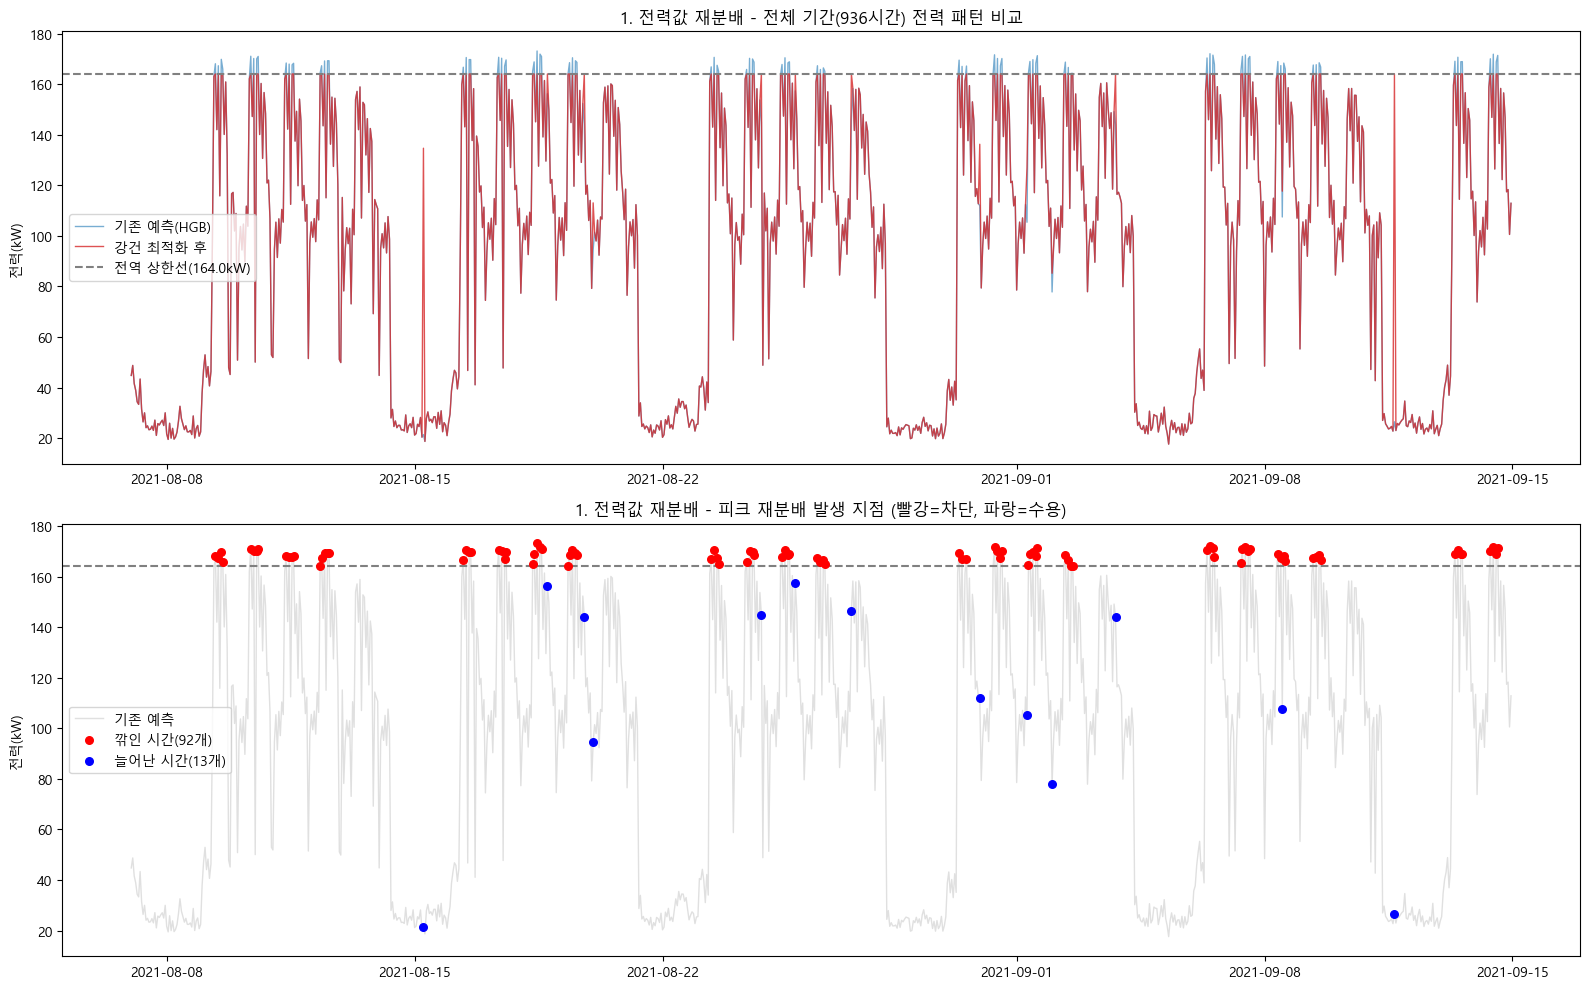

시각화 완료: card2_robust_optimization.png 저장됨


In [12]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨짐 방지 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ① 전체 936시간 비교
axes[0].plot(test.index, prediction, label='기존 예측(HGB)', color='tab:blue', alpha=0.6, linewidth=1)
axes[0].plot(test.index, schedule_v4, label='강건 최적화 후', color='tab:red', alpha=0.8, linewidth=1)
axes[0].axhline(y=strict_peak_limit, color='gray', linestyle='--', label=f'전역 상한선({strict_peak_limit:.1f}kW)')
axes[0].set_title('1. 전력값 재분배 - 전체 기간(936시간) 전력 패턴 비교')
axes[0].set_ylabel('전력(kW)')
axes[0].legend()

# ② 깎인 시간(빨강) / 늘어난 시간(파랑) 강조
axes[1].plot(test.index, prediction, color='lightgray', alpha=0.7, linewidth=1, label='기존 예측')
decreased_mask = np.array(schedule_v4) < (prediction - 0.01)
increased_mask = np.array(schedule_v4) > (prediction + 0.01)

axes[1].scatter(test.index[decreased_mask], prediction[decreased_mask],
                color='red', s=30, label=f'깎인 시간({decreased_mask.sum()}개)', zorder=5)
axes[1].scatter(test.index[increased_mask], prediction[increased_mask],
                color='blue', s=30, label=f'늘어난 시간({increased_mask.sum()}개)', zorder=5)
axes[1].axhline(y=strict_peak_limit, color='gray', linestyle='--')
axes[1].set_title('1. 전력값 재분배 - 피크 재분배 발생 지점 (빨강=차단, 파랑=수용)')
axes[1].set_ylabel('전력(kW)')
axes[1].legend()

plt.tight_layout()
plt.savefig('card2_robust_optimization.png', dpi=150)
plt.show()

print("시각화 완료: card2_robust_optimization.png 저장됨")


## 2. 생산량 재배치 (±20%, CP-SAT)
**아이디어**: 각 시간의 생산량을 80~120%(4%씩) 후보 중 하나로 바꿔서 총생산량은 유지한 채
HGB 예측 피크의 상한 초과분을 최소화할 수 있는지 CP-SAT(정수계획)로 탐색.
**결과**: 상한초과분 감소율 0%. 생산량을 바꿔도 HGB 예측 피크가 거의 달라지지 않음 → 생산량은 피크의 핵심 변수가 아님을 시사.

In [13]:
# ===== 설정과 데이터 준비 =====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

TARGETS = ["15분", "30분", "45분", "60분"]

RATIO_PERCENT = np.arange(80, 121, 4)
LIMIT = 164.0
TIME_LIMIT = 120
OBJECTIVE_SCALE = 1_000_000
EPS = 1e-6

# 한글 글꼴 설정
available_fonts = {
    font.name for font in font_manager.fontManager.ttflist
}

for font in [
    "Malgun Gothic",
    "AppleGothic",
    "NanumGothic",
    "Noto Sans CJK KR",
]:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams["axes.unicode_minus"] = False

# Best_Way.py가 만든 객체를 그대로 사용
data = test.copy()

if (
    data.empty
    or not isinstance(data.index, pd.DatetimeIndex)
    or data.index.hasnans
    or not data.index.is_unique
    or not data.index.is_monotonic_increasing
):
    raise ValueError("테스트 데이터 또는 시간 인덱스가 올바르지 않습니다.")

required_columns = ["생산량", "기온", "풍속", "습도", "강수량"]

if not set(required_columns).issubset(data.columns):
    raise ValueError("생산량 또는 날씨 입력 열이 없습니다.")

for column in required_columns:
    data[column] = pd.to_numeric(data[column], errors="coerce")

if not np.isfinite(data[required_columns].to_numpy(dtype=float)).all():
    raise ValueError("입력 데이터에 결측값 또는 무한대가 있습니다.")

original = data["생산량"].to_numpy(dtype=float)

if (original < 0).any():
    raise ValueError("생산량에 음수가 있습니다.")

# 원본 생산량이 정수인 현재 데이터를 기준으로 사용
if not np.allclose(original, np.rint(original), rtol=0, atol=1e-8):
    raise ValueError(
        "원본 생산량에 소수점이 있습니다. "
        "임의 반올림 없이 정밀도를 먼저 확인해야 합니다."
    )

original_integer = np.rint(original).astype(np.int64)
n = len(data)
baseline_k = int(np.flatnonzero(RATIO_PERCENT == 100))

def predict_checked(candidate):
    """시간 인덱스와 전력 4열을 검사한 뒤 예측값 반환."""
    prediction = predict_power(candidate)

    if not isinstance(prediction, pd.DataFrame):
        raise TypeError("predict_power 결과가 DataFrame이 아닙니다.")

    if not prediction.index.equals(candidate.index):
        raise ValueError("후보 데이터와 예측의 시간 인덱스가 다릅니다.")

    if not set(TARGETS).issubset(prediction.columns):
        raise ValueError("예측 결과에 필요한 전력 열이 없습니다.")

    values = prediction[TARGETS].to_numpy(dtype=float)

    if not np.isfinite(values).all():
        raise ValueError("전력 예측값에 비정상 값이 있습니다.")

    return values

print("===== 모델·데이터 확인 =====")
print("테스트 성능:", test_metrics)
print(f"기간: {data.index.min()} ~ {data.index.max()}")
print(f"시간 수: {n:,}")
print(f"총생산량: {original.sum():,.2f}")
print(f"실험 상한: {LIMIT:g}")


===== 모델·데이터 확인 =====
테스트 성능: {'MAE': 10.162316973601072, 'RMSE': 14.51220470072972, 'R2': 0.940039407566114}
기간: 2021-08-07 00:00:00 ~ 2021-09-14 23:00:00
시간 수: 936
총생산량: 524,969.00
실험 상한: 164


In [14]:
# ===== 후보 예측과 개선 여지 확인 =====

# 생산량 × 100을 정수로 표현
production_units = (
    original_integer[:, None] * RATIO_PERCENT[None, :]
)

candidate_production = production_units / 100.0

# 시간 × 후보 × 전력 4구간
candidate_predictions = np.empty(
    (n, len(RATIO_PERCENT), len(TARGETS)),
    dtype=float,
)

for k, percent in enumerate(RATIO_PERCENT):
    candidate = data.copy()
    candidate["생산량"] = candidate_production[:, k]

    candidate_predictions[:, k, :] = predict_checked(candidate)
    print(f"생산량 {percent}% 후보 예측 완료")

candidate_peak = candidate_predictions.max(axis=2)
baseline_peak = candidate_peak[:, baseline_k]
baseline_max = float(baseline_peak.max())

candidate_excess = np.maximum(candidate_peak - LIMIT, 0.0)
baseline_excess = float(candidate_excess[:, baseline_k].sum())

# 기존 전체 최대피크보다 높아지는 후보는 선택하지 않음
options = []

for t in range(n):
    if original_integer[t] == 0:
        allowed = [baseline_k]
    else:
        allowed = [
            k for k in range(len(RATIO_PERCENT))
            if candidate_peak[t, k] <= baseline_max + 1e-8
        ]

    if baseline_k not in allowed:
        raise RuntimeError("기존 계획 후보가 누락됐습니다.")

    options.append(allowed)

# 총량 보존을 무시한 낙관적 하한
# 실제 최적화에서 달성 가능한 값이라는 뜻은 아님
optimistic_excess = sum(
    float(candidate_excess[t, options[t]].min())
    for t in range(n)
)

optimistic_max = max(
    float(candidate_peak[t, options[t]].min())
    for t in range(n)
)

improvement_upper_bound = max(
    baseline_excess - optimistic_excess, 0.0
)

print("\n===== 후보 평가 =====")
print(f"기존 최대 예측피크: {baseline_max:.4f}")
print(f"기존 상한 초과분 합: {baseline_excess:.4f}")
print(f"후보 기준 최대피크의 낙관적 하한: {optimistic_max:.4f}")
print(
    "후보 기준 초과분 합의 개선 가능량 상한:",
    f"{improvement_upper_bound:.4f}",
)
print("※ 낙관적 하한·상한은 총량 보존을 무시한 값입니다.")

if improvement_upper_bound <= EPS:
    print("\n선택한 후보 안에서 초과분 개선 여지가 없습니다.")
    print("다음 셀에서는 최적화를 건너뛰고 기존 계획을 유지합니다.")


생산량 80% 후보 예측 완료
생산량 84% 후보 예측 완료
생산량 88% 후보 예측 완료
생산량 92% 후보 예측 완료
생산량 96% 후보 예측 완료
생산량 100% 후보 예측 완료
생산량 104% 후보 예측 완료
생산량 108% 후보 예측 완료
생산량 112% 후보 예측 완료
생산량 116% 후보 예측 완료
생산량 120% 후보 예측 완료

===== 후보 평가 =====
기존 최대 예측피크: 181.3715
기존 상한 초과분 합: 1667.2057
후보 기준 최대피크의 낙관적 하한: 181.3715
후보 기준 초과분 합의 개선 가능량 상한: 56.5079
※ 낙관적 하한·상한은 총량 보존을 무시한 값입니다.


In [15]:
# ===== 후보 선택 최적화 =====

def optimize_candidates():
    baseline_selection = np.full(n, baseline_k, dtype=int)

    if improvement_upper_bound <= EPS:
        return baseline_selection, "개선 여지 없음 — 기존 계획 유지"

    from ortools.sat.python import cp_model

    model = cp_model.CpModel()

    choose = {
        (t, k): model.NewBoolVar(f"선택_{t}_{k}")
        for t in range(n)
        for k in options[t]
    }

    for t in range(n):
        model.AddExactlyOne([
            choose[t, k] for k in options[t]
        ])

    # 총생산량 × 100을 정확히 보존
    total_units = sum(int(v) for v in original_integer) * 100

    model.Add(
        sum(
            int(production_units[t, k]) * variable
            for (t, k), variable in choose.items()
        ) == total_units
    )

    # CP-SAT용 정수 목적계수
    excess_units = np.rint(
        candidate_excess * OBJECTIVE_SCALE
    ).astype(np.int64)

    change_units = np.abs(
        production_units - original_integer[:, None] * 100
    )

    excess_expression = sum(
        int(excess_units[t, k]) * variable
        for (t, k), variable in choose.items()
    )

    change_expression = sum(
        int(change_units[t, k]) * variable
        for (t, k), variable in choose.items()
    )

    def set_hint(selection):
        model.ClearHints()
        for (t, k), variable in choose.items():
            model.AddHint(variable, int(selection[t] == k))

    def solve():
        solver = cp_model.CpSolver()
        solver.parameters.max_time_in_seconds = TIME_LIMIT
        solver.parameters.num_search_workers = 4
        status = solver.Solve(model)
        return solver, status

    def read_selection(solver):
        selection = []

        for t in range(n):
            selected = [
                k for k in options[t]
                if solver.Value(choose[t, k]) == 1
            ]

            if len(selected) != 1:
                raise RuntimeError("시간별 후보 선택 검증에 실패했습니다.")

            selection.append(selected)

        return np.array(selection, dtype=int)

    def selected_sum(values, selection):
        return sum(
            int(values[t, selection[t]]) for t in range(n)
        )

    # 1단계
    set_hint(baseline_selection)
    model.Minimize(excess_expression)

    print("1단계: 상한 초과분 최소화")
    solver1, status1 = solve()

    if status1 in [cp_model.MODEL_INVALID, cp_model.INFEASIBLE]:
        raise RuntimeError(
            "기존 계획이 가능한 문제인데 모델이 실패했습니다. "
            f"상태: {solver1.StatusName(status1)}"
        )

    if status1 not in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
        return baseline_selection, "제한 시간 내 해 미확보 — 기존 계획 유지"

    selected1 = read_selection(solver1)
    excess1 = selected_sum(excess_units, selected1)

    print(
        "1단계 상태:",
        "정수화된 목적함수의 최적해 확인"
        if status1 == cp_model.OPTIMAL
        else "실행 가능한 해 확보 — 최적성 미확인",
    )

    # 2단계
    model.Add(excess_expression <= excess1)
    set_hint(selected1)
    model.Minimize(change_expression)

    print("2단계: 생산계획 변경량 최소화")
    solver2, status2 = solve()

    selected = selected1.copy()

    if status2 in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
        selected2 = read_selection(solver2)

        actual_excess1 = float(
            candidate_excess[np.arange(n), selected1].sum()
        )
        actual_excess2 = float(
            candidate_excess[np.arange(n), selected2].sum()
        )

        # 정수화로 인한 미세한 역전도 실제 예측값으로 확인
        if (
            selected_sum(change_units, selected2)
            <= selected_sum(change_units, selected1)
            and actual_excess2 <= actual_excess1 + 1e-8
        ):
            selected = selected2

        print(
            "2단계 상태:",
            "조건부 최적해 확인"
            if status2 == cp_model.OPTIMAL
            else "실행 가능한 해 확보 — 최적성 미확인",
        )
    else:
        print("2단계 해 미확보 — 1단계 결과 유지")

    actual_excess = float(
        candidate_excess[np.arange(n), selected].sum()
    )

    # 개선이 없으면 불필요하게 계획을 변경하지 않음
    if actual_excess >= baseline_excess - EPS:
        return baseline_selection, "실제 예측값 기준 개선 미확보 — 기존 계획 유지"

    note = (
        "1단계 정수화 목적함수 최적성 확인"
        if status1 == cp_model.OPTIMAL
        else "개선된 실행 가능 해 — 전역 최적성 미확인"
    )

    return selected, note

selected_k, optimization_note = optimize_candidates()

selected_units = production_units[np.arange(n), selected_k]
optimized_production = selected_units / 100.0

# 정수 기준으로 총량 검사
if sum(int(v) for v in selected_units) != (
    sum(int(v) for v in original_integer) * 100
):
    raise RuntimeError("총생산량 보존 검증에 실패했습니다.")

if (
    (selected_units < original_integer * 80).any()
    or (selected_units > original_integer * 120).any()
):
    raise RuntimeError("시간별 생산량 ±20% 조건을 벗어났습니다.")

if (selected_units[original_integer == 0] != 0).any():
    raise RuntimeError("기존 비생산 시간에 신규 생산이 발생했습니다.")

print("\n===== 최적화 종료 =====")
print(optimization_note)
print("정수 기준 총생산량 보존: 통과")
print("시간별 생산량 ±20%: 통과")
print("생산량 0인 시간 유지: 통과")


1단계: 상한 초과분 최소화
1단계 상태: 정수화된 목적함수의 최적해 확인
2단계: 생산계획 변경량 최소화
2단계 상태: 조건부 최적해 확인

===== 최적화 종료 =====
실제 예측값 기준 개선 미확보 — 기존 계획 유지
정수 기준 총생산량 보존: 통과
시간별 생산량 ±20%: 통과
생산량 0인 시간 유지: 통과


===== 최종 결과 =====
실제 예측값 기준 개선 미확보 — 기존 계획 유지
                    기존 계획        변경 계획   변화
총생산량          524969.0000  524969.0000  0.0
전체 최대 예측피크       181.3715     181.3715  0.0
상한 초과 시간 수       189.0000     189.0000  0.0
상한 초과분 합        1667.2057    1667.2057  0.0
생산량 변경 절대값 합       0.0000       0.0000  0.0

상한 초과분 합 감소율: 0.0000%

월별 생산량:
             기존 생산량    변경 생산량
timestamp                    
2021-08    344205.0  344205.0
2021-09    180764.0  180764.0

학습 생산량 범위를 벗어난 시간: 0

주의: 모델 기반 시나리오 결과입니다.
상한 초과분 합은 전력량·실제 전기료가 아닙니다.
납기·재고·설비능력·기동비용은 반영하지 않았습니다.
학습 생산량 범위 안이라는 사실만으로 예측 신뢰성이 보장되지는 않습니다.


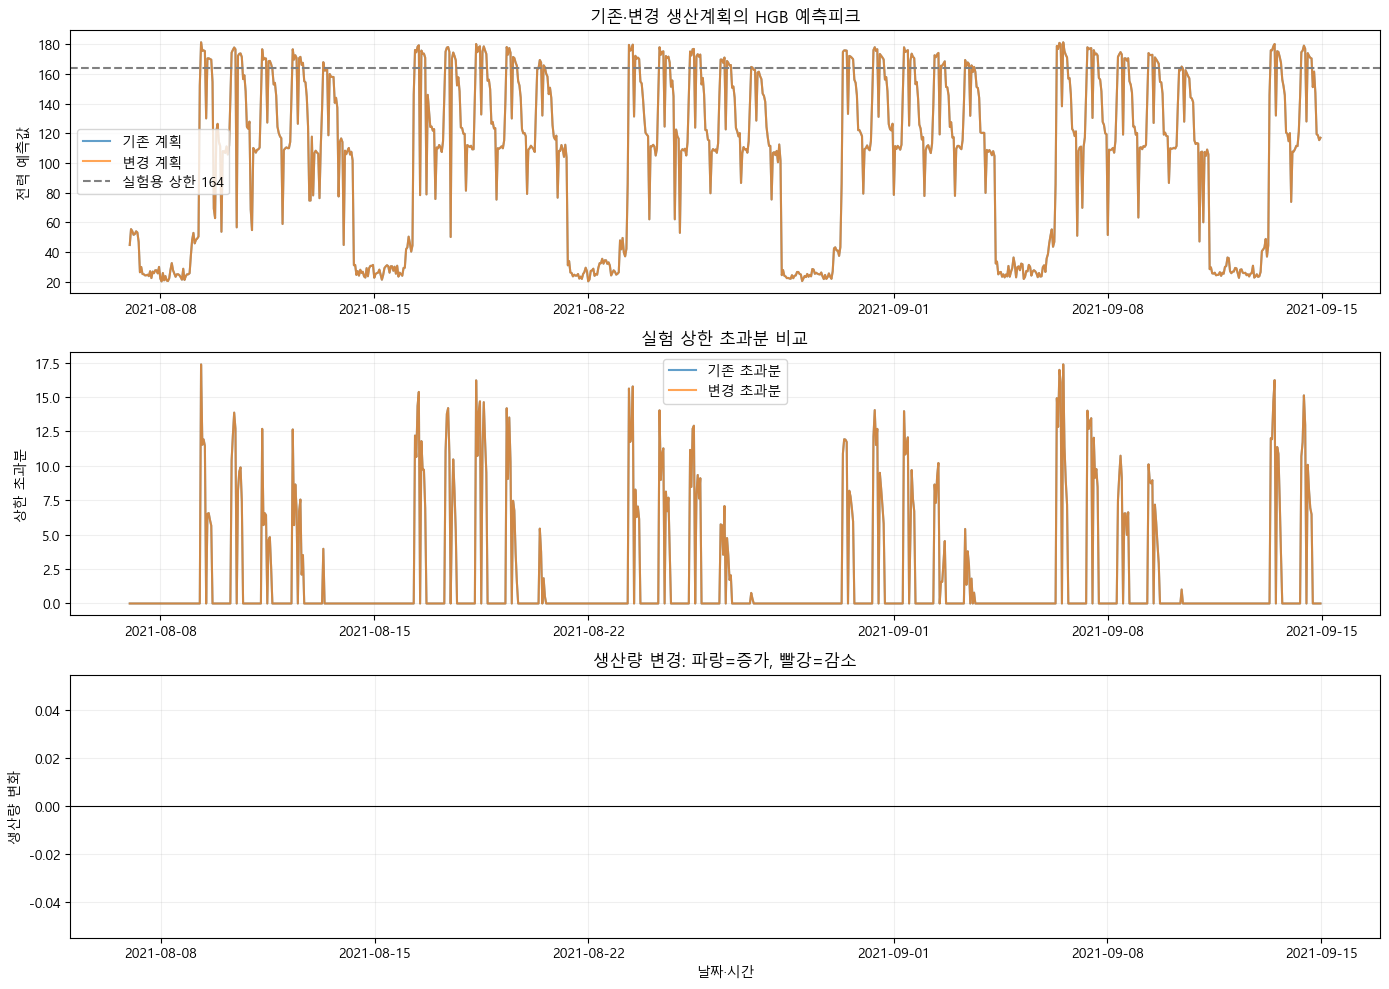

In [16]:
# ===== 최종 재예측 검증·결과 비교 =====

final_candidate = data.copy()
final_candidate["생산량"] = optimized_production

final_prediction = predict_checked(final_candidate)

selected_prediction = candidate_predictions[
    np.arange(n), selected_k, :
]

if not np.allclose(
    final_prediction,
    selected_prediction,
    rtol=0,
    atol=1e-6,
):
    raise RuntimeError(
        "후보 예측과 최종 재예측이 다릅니다. "
        "predict_power의 행 간 의존성 또는 입력 처리 확인이 필요합니다."
    )

final_peak = final_prediction.max(axis=1)

if final_peak.max() > baseline_max + EPS:
    raise RuntimeError("전체 최대 예측피크가 기존보다 증가했습니다.")

result = pd.DataFrame({
    "기존 생산량": original,
    "변경 생산량": optimized_production,
    "기존 예측피크": baseline_peak,
    "변경 예측피크": final_peak,
}, index=data.index)

result["생산량 변화"] = (
    result["변경 생산량"] - result["기존 생산량"]
)

def summarize(production, peak):
    return pd.Series({
        "총생산량": float(production.sum()),
        "전체 최대 예측피크": float(peak.max()),
        "상한 초과 시간 수": int((peak > LIMIT + EPS).sum()),
        "상한 초과분 합": float(np.maximum(peak - LIMIT, 0).sum()),
        "생산량 변경 절대값 합": float(
            np.abs(production - original).sum()
        ),
    })

comparison = pd.DataFrame({
    "기존 계획": summarize(original, baseline_peak),
    "변경 계획": summarize(optimized_production, final_peak),
})

comparison["변화"] = (
    comparison["변경 계획"] - comparison["기존 계획"]
)

print("===== 최종 결과 =====")
print(optimization_note)
print(comparison.round(4).to_string())

after_excess = float(np.maximum(final_peak - LIMIT, 0).sum())

if baseline_excess > 0:
    reduction = (
        (baseline_excess - after_excess) / baseline_excess * 100
    )
    print(f"\n상한 초과분 합 감소율: {reduction:.4f}%")

monthly_result = (
    result[["기존 생산량", "변경 생산량"]]
    .groupby(result.index.to_period("M"))
    .sum()
)

print("\n월별 생산량:")
print(monthly_result.round(2).to_string())

# 학습 생산량 범위를 벗어나는지 확인
training_production = pd.to_numeric(
    train["생산량"], errors="coerce"
).dropna()

if not training_production.empty:
    outside = (
        (optimized_production < training_production.min())
        | (optimized_production > training_production.max())
    )
    print("\n학습 생산량 범위를 벗어난 시간:", int(outside.sum()))

print(
    "\n주의: 모델 기반 시나리오 결과입니다."
    "\n상한 초과분 합은 전력량·실제 전기료가 아닙니다."
    "\n납기·재고·설비능력·기동비용은 반영하지 않았습니다."
    "\n학습 생산량 범위 안이라는 사실만으로 예측 신뢰성이 보장되지는 않습니다."
)

# ===== 그래프: 수정본 =====

# 오류로 생성된 빈 그래프 닫기
plt.close("all")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# ① 기존·변경 예측피크
axes[0].plot(
    data.index,
    baseline_peak,
    label="기존 계획",
    alpha=0.7,
)

axes[0].plot(
    data.index,
    final_peak,
    label="변경 계획",
    alpha=0.7,
)

axes[0].axhline(
    LIMIT,
    color="gray",
    linestyle="--",
    label=f"실험용 상한 {LIMIT:g}",
)

axes[0].set_title("기존·변경 생산계획의 HGB 예측피크")
axes[0].set_ylabel("전력 예측값")
axes[0].legend()

# ② 실험 상한 초과분
axes[1].plot(
    data.index,
    np.maximum(baseline_peak - LIMIT, 0),
    label="기존 초과분",
    alpha=0.7,
)

axes[1].plot(
    data.index,
    np.maximum(final_peak - LIMIT, 0),
    label="변경 초과분",
    alpha=0.7,
)

axes[1].set_title("실험 상한 초과분 비교")
axes[1].set_ylabel("상한 초과분")
axes[1].legend()

# ③ 시간별 생산량 변경
colors = np.where(
    result["생산량 변화"] >= 0,
    "tab:blue",
    "tab:red",
)

axes[2].bar(
    result.index,
    result["생산량 변화"],
    width=0.035,
    color=colors,
)

axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("생산량 변경: 파랑=증가, 빨강=감소")
axes[2].set_ylabel("생산량 변화")
axes[2].set_xlabel("날짜·시간")

for ax in axes:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [17]:
#생산량 조정과 전력예측을 연결한 후보 선택 실험을 수행했으나, 
#현재 모델·후보·제약 및 계산 조건에서 개선된 생산계획을 확보하지 못했다. 
#현장 적용을 위해서는 운영 제약과 계획 변경에 대한 모델 검증이 추가로 필요하다

## 4. 매칭 최적화 (유사 사례 참조)
**아이디어**: 생산량과 날씨(기온±3, 습도±10)가 비슷한 과거 시점을 찾아, 그 시점의 생산량으로 운영했다면
더 낮은 피크를 기록했을지 확인.
**1차 결과(관측치 기준)**: 643/936시간에서 참고 사례 발견, 평균 개선폭 25.75 — 하지만 상위 매칭들이 대부분 계절이 다른 시점(여름↔봄)이었음 → 계절효과로 의심.
**재검증(HGB로 재예측)**: 참고 생산량으로 바꿔서 실제로 HGB에 다시 넣어 예측해보니, 개선 확인된 사례는 24건(3.7%), 평균 개선폭 0.43으로 급감.
→ 매칭에서 보인 '개선'은 생산량·날씨가 아니라 **측정되지 않은 다른 요인**(계절, 설비 운전방식 등) 때문임이 드러남.

In [18]:
# ===== 사전 확인: 같은 생산량대에서 피크 편차가 있는가 =====

import numpy as np
import pandas as pd

TARGETS = ["15분", "30분", "45분", "60분"]

check_data = train.copy()  # 참고 사례 풀로 쓸 학습 구간
check_data["실제피크"] = check_data[TARGETS].max(axis=1)

# 생산량을 20개 구간으로 나눠 구간별 피크 편차 확인
check_data["생산량구간"] = pd.qcut(check_data["생산량"], 20, duplicates="drop")

bucket_stats = check_data.groupby("생산량구간", observed=True)["실제피크"].agg(
    ["mean", "std", "min", "max", "count"]
)

print("===== 생산량 구간별 실제피크 분포 =====")
print(bucket_stats.round(2).to_string())

print(
    "\n확인 포인트: 같은 생산량 구간인데도 std(표준편차)가 크고 "
    "min과 max의 차이가 크다면, 매칭 최적화 아이디어가 성립합니다."
)


===== 생산량 구간별 실제피크 분포 =====
                     mean    std  min  max  count
생산량구간                                            
(-0.001, 4.0]       55.40  50.75   20  208   1928
(4.0, 35.0]        109.36  27.04   21  174    211
(35.0, 78.0]       109.37  25.37   21  178    213
(78.0, 136.0]      110.75  26.22   20  178    216
(136.0, 235.3]     115.25  27.02   21  208    209
(235.3, 399.7]     124.67  37.93   21  222    213
(399.7, 615.0]     139.92  40.63   21  208    215
(615.0, 825.0]     155.73  37.10   22  201    214
(825.0, 1059.35]   160.53  31.40   22  204    212
(1059.35, 1455.0]  163.03  27.67   22  202    214
(1455.0, 2081.35]  156.00  28.45   23  222    213
(2081.35, 9830.0]  153.79  32.07   22  198    214

확인 포인트: 같은 생산량 구간인데도 std(표준편차)가 크고 min과 max의 차이가 크다면, 매칭 최적화 아이디어가 성립합니다.


In [19]:
# ===== 매칭 최적화: 데이터 준비 (생산량 + 날씨 동시 유사) =====

import numpy as np
import pandas as pd

TARGETS = ["15분", "30분", "45분", "60분"]
SIMILARITY_BAND = 0.10          # 생산량 유사도 허용폭(실험 조건)
ZERO_PRODUCTION_ABS_BAND = 5.0  # 생산량이 0에 가까울 때의 절대 허용폭(실험 조건)
WEATHER_COLUMNS = ["기온", "습도"]
WEATHER_BAND = {"기온": 3.0, "습도": 10.0}  # 실험 조건(절대 허용폭)

required_names = ["train", "test"]
missing_names = [n for n in required_names if n not in globals()]
if missing_names:
    raise RuntimeError(f"먼저 Best_Way.py를 실행하세요. 없는 객체: {missing_names}")

# ----- 참고 풀: train 구간 (반드시 과거 데이터만 사용, 미래 누수 방지) -----
reference_pool = train.copy()

required_columns = ["생산량"] + TARGETS + WEATHER_COLUMNS
if not set(required_columns).issubset(reference_pool.columns):
    raise ValueError("참고 풀에 필요한 열이 없습니다.")

for col in required_columns:
    reference_pool[col] = pd.to_numeric(reference_pool[col], errors="coerce")

reference_pool["실제피크"] = reference_pool[TARGETS].max(axis=1)
reference_pool = reference_pool.dropna(subset=required_columns + ["실제피크"]).reset_index()
reference_pool = reference_pool.rename(columns={reference_pool.columns[0]: "참고시각"})

# ----- 매칭 대상: test 구간 -----
target_data = test.copy()
if not set(required_columns).issubset(target_data.columns):
    raise ValueError("테스트 데이터에 필요한 열이 없습니다.")

for col in required_columns:
    target_data[col] = pd.to_numeric(target_data[col], errors="coerce")

target_data["실제피크"] = target_data[TARGETS].max(axis=1)
target_data = target_data.dropna(subset=required_columns + ["실제피크"])

if not np.isfinite(target_data[required_columns + ["실제피크"]].to_numpy(dtype=float)).all():
    raise ValueError("테스트 데이터에 비정상 값이 있습니다.")

ref_prod = reference_pool["생산량"].to_numpy(dtype=float)
ref_peak = reference_pool["실제피크"].to_numpy(dtype=float)
ref_weather = {col: reference_pool[col].to_numpy(dtype=float) for col in WEATHER_COLUMNS}

tgt_prod = target_data["생산량"].to_numpy(dtype=float)
tgt_peak_actual = target_data["실제피크"].to_numpy(dtype=float)
tgt_weather = {col: target_data[col].to_numpy(dtype=float) for col in WEATHER_COLUMNS}

n_t = len(target_data)
n_r = len(reference_pool)

print("===== 데이터 준비 완료 =====")
print(f"참고 풀(train) 크기: {n_r:,}")
print(f"매칭 대상(test) 크기: {n_t:,}")

# ----- 시간 t별로 매칭 가능한 참고 후보 r 찾기 -----
# 조건 1: 생산량이 비슷함
# 조건 2: 기온·습도가 모두 허용폭 이내로 비슷함
# 조건 3: 참고 기록의 실제피크가 자기 자신(test)의 실제피크보다 낮음

candidate_lists = []
no_candidate_count = 0

for t in range(n_t):
    p = tgt_prod[t]

    if p < ZERO_PRODUCTION_ABS_BAND:
        mask = np.abs(ref_prod - p) <= ZERO_PRODUCTION_ABS_BAND
    else:
        mask = np.abs(ref_prod - p) <= p * SIMILARITY_BAND

    for col in WEATHER_COLUMNS:
        mask &= np.abs(ref_weather[col] - tgt_weather[col][t]) <= WEATHER_BAND[col]

    mask &= ref_peak < tgt_peak_actual[t]

    candidates = np.flatnonzero(mask)

    if len(candidates) == 0:
        no_candidate_count += 1

    candidate_lists.append(candidates)

print(f"\n참고 가능한 시간: {n_t - no_candidate_count:,} / {n_t:,}")
print(f"참고 후보가 없는 시간(이미 최선이거나 유사 사례 없음): {no_candidate_count:,}")


===== 데이터 준비 완료 =====
참고 풀(train) 크기: 4,272
매칭 대상(test) 크기: 936

참고 가능한 시간: 643 / 936
참고 후보가 없는 시간(이미 최선이거나 유사 사례 없음): 293


In [20]:
# ===== 매칭 최적화: 시간별로 가장 낮은 참고피크를 가진 유사 사례 선택 =====

from ortools.linear_solver import pywraplp

solver = pywraplp.Solver.CreateSolver("GLOP")
if solver is None:
    raise RuntimeError("솔버를 생성하지 못했습니다.")

# 각 시간 t는 자신의 후보 중 하나를 선택(연속 가중치 혼합도 허용)
# 목적: 선택된 참고피크의 기대값(가중 평균) 최소화
# 제약: 가중치 합 = 1 (후보가 있는 경우에만)

choose_vars = {}

for t in range(n_t):
    candidates = candidate_lists[t]
    if len(candidates) == 0:
        continue
    for r in candidates:
        choose_vars[(t, r)] = solver.NumVar(0, 1, f"w_{t}_{r}")

for t in range(n_t):
    candidates = candidate_lists[t]
    if len(candidates) == 0:
        continue
    solver.Add(
        solver.Sum(choose_vars[(t, r)] for r in candidates) == 1
    )

objective = solver.Objective()
for (t, r), var in choose_vars.items():
    objective.SetCoefficient(var, float(ref_peak[r]))
objective.SetMinimization()

status = solver.Solve()

if status != pywraplp.Solver.OPTIMAL:
    raise RuntimeError(f"최적해를 찾지 못했습니다. 상태 코드: {status}")

# ----- 결과 정리 -----
# 연속 가중치 중 가장 비중이 큰 후보 하나를 "대표 참고 사례"로 선택(설명 용이성 위함)
match_result = []

for t in range(n_t):
    candidates = candidate_lists[t]

    if len(candidates) == 0:
        match_result.append({
            "참고사례_있음": False,
            "참고시각": pd.NaT,
            "참고생산량": np.nan,
            "참고피크": np.nan,
        })
        continue

    weights = np.array([choose_vars[(t, r)].solution_value() for r in candidates])
    best_r = candidates[int(np.argmax(weights))]

    match_result.append({
        "참고사례_있음": True,
        "참고시각": reference_pool.loc[best_r, "참고시각"],
        "참고생산량": float(reference_pool.loc[best_r, "생산량"]),
        "참고피크": float(reference_pool.loc[best_r, "실제피크"]),
    })

match_df = pd.DataFrame(match_result, index=target_data.index)
match_df["자신_생산량"] = tgt_prod
match_df["자신_실제피크"] = tgt_peak_actual
match_df["참고_개선폭"] = match_df["자신_실제피크"] - match_df["참고피크"]

matched_only = match_df[match_df["참고사례_있음"]]

print("===== 매칭 최적화 결과 =====")
print(f"참고 사례를 찾은 시간: {len(matched_only):,} / {n_t:,}")
print(f"\n평균 개선폭(참고 사례 기준): {matched_only['참고_개선폭'].mean():.2f}")
print(f"최대 개선폭: {matched_only['참고_개선폭'].max():.2f}")

print("\n개선폭 상위 10개 시간:")
print(
    matched_only.sort_values("참고_개선폭", ascending=False)
    .head(10)[["자신_생산량", "자신_실제피크", "참고시각", "참고생산량", "참고피크", "참고_개선폭"]]
    .round(2)
    .to_string()
)


===== 매칭 최적화 결과 =====
참고 사례를 찾은 시간: 643 / 936

평균 개선폭(참고 사례 기준): 25.75
최대 개선폭: 154.00

개선폭 상위 10개 시간:
                     자신_생산량  자신_실제피크                참고시각  참고생산량  참고피크  참고_개선폭
timestamp                                                                    
2021-09-02 15:00:00   929.0    177.0 2021-05-19 08:00:00  841.0  23.0   154.0
2021-09-14 08:00:00   432.0    184.0 2021-06-08 00:00:00  400.0  64.0   120.0
2021-09-10 08:00:00   196.0    192.0 2021-06-24 00:00:00  200.0  73.0   119.0
2021-08-17 12:00:00     0.0    134.0 2021-05-16 16:00:00    0.0  20.0   114.0
2021-09-09 20:00:00     2.0    134.0 2021-05-16 16:00:00    0.0  20.0   114.0
2021-08-10 08:00:00   503.0    195.0 2021-06-15 00:00:00  468.0  83.0   112.0
2021-09-10 13:00:00   838.0    191.0 2021-06-19 07:00:00  844.0  82.0   109.0
2021-08-13 20:00:00     0.0    125.0 2021-05-16 15:00:00    0.0  20.0   105.0
2021-09-09 08:00:00   434.0    187.0 2021-06-15 00:00:00  468.0  83.0   104.0
2021-08-24 20:00:00     0.0    125.0 202

===== HGB 기준 재검증 =====
관측 데이터 기준 개선 사례: 643
HGB 예측으로도 개선이 확인된 사례: 24 (3.7%)

HGB 기준 평균 개선폭: 0.43

주의:
이 결과는 '참고 사례의 생산량으로 운영했다면'이라는 가정 시나리오입니다.
실제로 그 생산량 수준을 재현할 수 있는지는 현장 확인이 필요합니다.


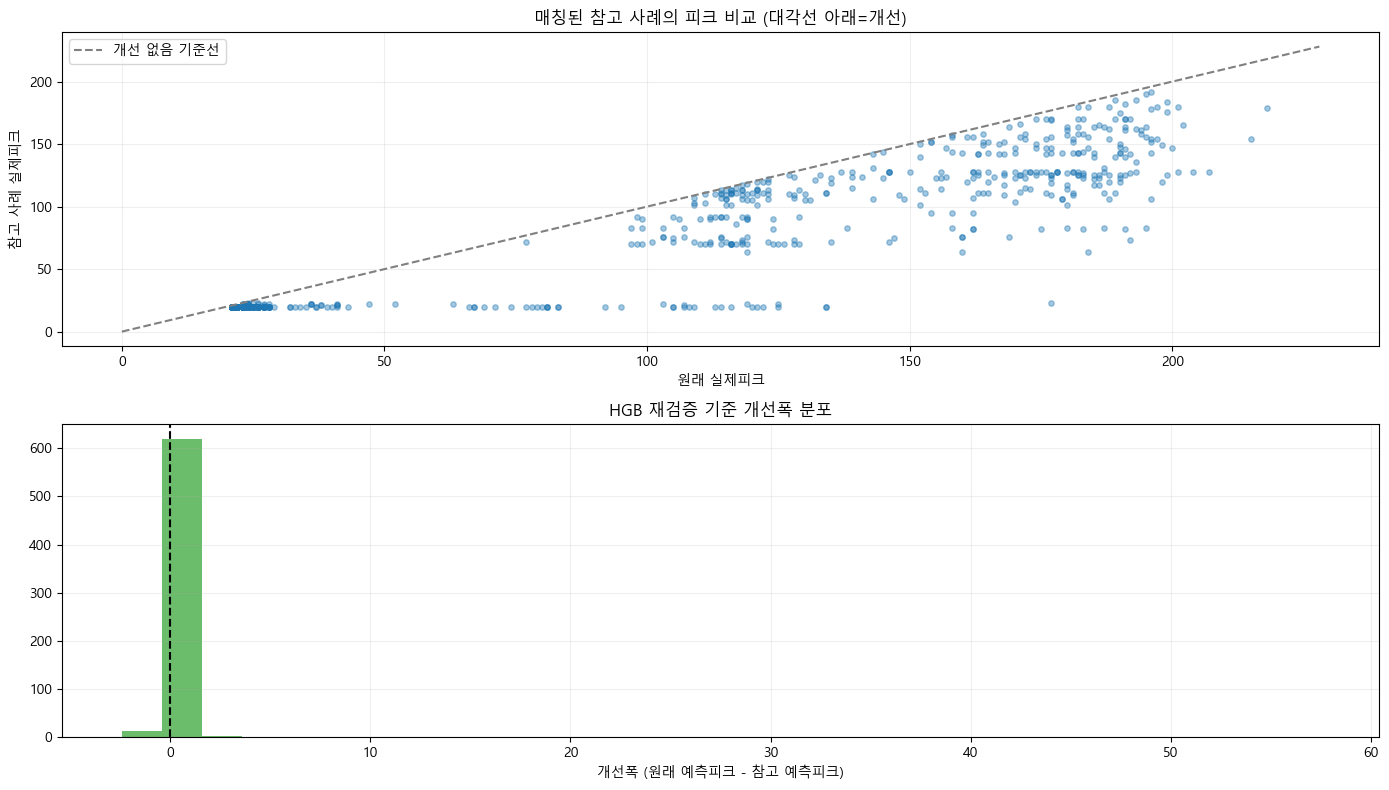

In [21]:
# ===== HGB 재검증 =====

verify_rows = matched_only.copy()
candidate_input = target_data.loc[verify_rows.index].copy()
candidate_input["생산량"] = verify_rows["참고생산량"].to_numpy()

verify_prediction = predict_power(candidate_input)

if not isinstance(verify_prediction, pd.DataFrame):
    raise TypeError("예측 결과가 DataFrame이 아닙니다.")
if not verify_prediction.index.equals(candidate_input.index):
    raise ValueError("예측 결과의 시간 인덱스가 다릅니다.")

verify_rows["참고_예측피크(HGB)"] = verify_prediction[TARGETS].max(axis=1).to_numpy()

original_prediction = predict_power(target_data.loc[verify_rows.index])
verify_rows["원래_예측피크(HGB)"] = original_prediction[TARGETS].max(axis=1).to_numpy()

verify_rows["HGB기준_개선폭"] = (
    verify_rows["원래_예측피크(HGB)"] - verify_rows["참고_예측피크(HGB)"]
)

improved_by_hgb = int((verify_rows["HGB기준_개선폭"] > 0.01).sum())

print("===== HGB 기준 재검증 =====")
print(f"관측 데이터 기준 개선 사례: {len(verify_rows):,}")
print(f"HGB 예측으로도 개선이 확인된 사례: {improved_by_hgb:,} ({improved_by_hgb / len(verify_rows) * 100:.1f}%)")
print(f"\nHGB 기준 평균 개선폭: {verify_rows['HGB기준_개선폭'].mean():.2f}")

print("\n주의:")
print("이 결과는 '참고 사례의 생산량으로 운영했다면'이라는 가정 시나리오입니다.")
print("실제로 그 생산량 수준을 재현할 수 있는지는 현장 확인이 필요합니다.")

# 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].scatter(
    verify_rows["자신_실제피크"], verify_rows["참고피크"],
    alpha=0.4, s=15, color="tab:blue",
)
lims = [0, max(verify_rows["자신_실제피크"].max(), verify_rows["참고피크"].max()) + 10]
axes[0].plot(lims, lims, color="gray", linestyle="--", label="개선 없음 기준선")
axes[0].set_xlabel("원래 실제피크")
axes[0].set_ylabel("참고 사례 실제피크")
axes[0].set_title("매칭된 참고 사례의 피크 비교 (대각선 아래=개선)")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].hist(verify_rows["HGB기준_개선폭"], bins=30, color="tab:green", alpha=0.7)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("HGB 재검증 기준 개선폭 분포")
axes[1].set_xlabel("개선폭 (원래 예측피크 - 참고 예측피크)")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [22]:
#동일한 생산량, 동일한 수준의 기온·습도에서도 피크가 크게 다르다면, 그 차이는 생산량이나 측정된 날씨 변수로는 설명되지 않는다. 즉 생산량 조정 중심의 최적화(1~2번에서 계속 시도)가 효과가 제한적이었던 근본 원인이, 현재 데이터에 기록되지 않은 다른 요인(설비 운전 방식, 중복가동, 계절적 기기 전환 등)에 있을 가능성이 높다

## 5. 안전마진 최적화 (Water-filling LP)
**아이디어**: train 구간에서 '실제-예측 > 0'(과소예측)인 오차를 24개 시간대에 예산으로 배분(LP)해서
초과분을 최소화하고, 이 시간대별 배분이 test에서도 평탄배분(모든 시간 동일 배분)보다 나은지 비교.
**결과**: 예산 0~300까지는 거의 동일(±0.4%). 예산 400 이상에서는 오히려 **평탄배분이 더 우수**(개선율 -5%~-19%).
→ train에서 학습한 시간대별 위험 순위가 test에서 재현되지 않음(과적합). 시간대만으로는 위험을 안정적으로 구분할 수 없음.

In [23]:
# ===== 예측오차 기반 안전마진 최적화: 데이터 준비 =====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

TARGETS = ["15분", "30분", "45분", "60분"]

required_names = ["train", "test", "predict_power"]
missing_names = [n for n in required_names if n not in globals()]
if missing_names:
    raise RuntimeError(f"먼저 Best_Way.py를 실행하세요. 없는 객체: {missing_names}")

# 한글 글꼴
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"]:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break
plt.rcParams["axes.unicode_minus"] = False


def make_peak_table(source):
    """실제·예측 전력 4열의 최댓값(시간별 피크)을 같은 인덱스로 정리."""

    if (
        source.empty
        or not isinstance(source.index, pd.DatetimeIndex)
        or source.index.hasnans
        or not source.index.is_unique
        or not source.index.is_monotonic_increasing
    ):
        raise ValueError("데이터 또는 시간 인덱스가 올바르지 않습니다.")

    if not set(TARGETS).issubset(source.columns):
        raise ValueError("실제 전력 4열이 없습니다.")

    actual_values = (
        source[TARGETS].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    )

    prediction = predict_power(source.copy())

    if not isinstance(prediction, pd.DataFrame):
        raise TypeError("예측 결과가 DataFrame이 아닙니다.")
    if not prediction.index.equals(source.index):
        raise ValueError("실제값과 예측값의 시간 인덱스가 다릅니다.")
    if not set(TARGETS).issubset(prediction.columns):
        raise ValueError("예측 결과에 전력 4열이 없습니다.")

    predicted_values = prediction[TARGETS].to_numpy(dtype=float)

    if not np.isfinite(actual_values).all() or not np.isfinite(predicted_values).all():
        raise ValueError("실제값 또는 예측값에 비정상 값이 있습니다.")

    table = pd.DataFrame(
        {
            "실제피크": actual_values.max(axis=1),
            "예측피크": predicted_values.max(axis=1),
        },
        index=source.index,
    )
    table["시간"] = source.index.hour
    return table


# train: 예산 배분(LP)을 학습하는 구간 / test: 바깥 검증 구간 (시간상 train이 앞섬)
train_peak = make_peak_table(train)
test_peak = make_peak_table(test)

# 과소예측 리스크만 다룸: 실제가 예측보다 높았던 양(+)의 오차
train_peak["오차"] = train_peak["실제피크"] - train_peak["예측피크"]
test_peak["오차"] = test_peak["실제피크"] - test_peak["예측피크"]

print("===== 데이터 준비 완료 =====")
print(f"train 행 수: {len(train_peak):,} / test 행 수: {len(test_peak):,}")
print(f"train 기간: {train_peak.index.min()} ~ {train_peak.index.max()}")
print(f"test 기간: {test_peak.index.min()} ~ {test_peak.index.max()}")

print("\n[train] 시간대별 과소예측 오차(양수만) 요약:")
hourly_error_summary = (
    train_peak.assign(양의오차=train_peak["오차"].clip(lower=0))
    .groupby("시간")["양의오차"]
    .agg(["mean", "std", "max", "count"])
)
print(hourly_error_summary.round(2).to_string())

print(
    "\n참고: test_metrics(검증된 전체 성능) =", test_metrics,
    "\n이번 분석은 이 성능 뒤에 숨은 '시간대별 오차 편차'를 활용합니다."
)


===== 데이터 준비 완료 =====
train 행 수: 4,272 / test 행 수: 936
train 기간: 2021-01-01 00:00:00 ~ 2021-06-27 23:00:00
test 기간: 2021-08-07 00:00:00 ~ 2021-09-14 23:00:00

[train] 시간대별 과소예측 오차(양수만) 요약:
     mean    std     max  count
시간                             
0    3.18   5.97   26.26    178
1    7.00   9.62   49.56    178
2    7.48  10.02   55.79    178
3    7.29  10.07   45.21    178
4    6.47   9.05   53.07    178
5    6.83  10.95   46.96    178
6    6.84  10.23   64.69    178
7    7.99  11.63   90.89    178
8   11.29  19.64  121.71    178
9    8.02  15.02  101.34    178
10   6.76  14.04  112.54    178
11   7.19  13.90   82.24    178
12   3.98  10.45   65.32    178
13   7.92  11.70   64.77    178
14   6.80  13.42   91.60    178
15   6.72  12.91   74.65    178
16   4.76  11.55   79.34    178
17   7.19  12.19   68.35    178
18   8.28  14.18   96.91    178
19   8.45  14.16   80.85    178
20   7.22  12.49   73.90    178
21   5.94  10.00   58.71    178
22   5.16  10.44   61.83    178
23   5.69  

In [24]:
# ===== 안전마진 예산의 시간대별 최적 배분 (LP) =====

from ortools.linear_solver import pywraplp

HOURS = list(range(24))

train_hour = train_peak["시간"].to_numpy()
train_residual = train_peak["오차"].to_numpy(dtype=float)

# 시간대별 train 표본 수가 최적화에 쓰일 만큼 있는지 확인
hour_counts = train_peak.groupby("시간").size()
if (hour_counts < 30).any():
    print("주의: 일부 시간대의 train 표본이 30개 미만입니다. 해당 시간대 마진은 불안정할 수 있습니다.")
    print(hour_counts[hour_counts < 30].to_string())


def solve_water_filling(budget):
    """총 예산 budget을 24개 시간대에 배분해 총 과소예측량(초과분 합)을 최소화."""

    solver = pywraplp.Solver.CreateSolver("GLOP")
    if solver is None:
        raise RuntimeError("GLOP 솔버를 생성하지 못했습니다.")

    margin = {h: solver.NumVar(0, solver.infinity(), f"margin_{h}") for h in HOURS}

    solver.Add(solver.Sum(margin[h] for h in HOURS) <= float(budget))

    shortfall_vars = []
    for i in range(len(train_residual)):
        h = int(train_hour[i])
        s = solver.NumVar(0, solver.infinity(), f"shortfall_{i}")
        solver.Add(s >= train_residual[i] - margin[h])
        shortfall_vars.append(s)

    solver.Minimize(solver.Sum(shortfall_vars))

    status = solver.Solve()
    if status != pywraplp.Solver.OPTIMAL:
        raise RuntimeError(f"LP 최적해를 찾지 못했습니다. 상태 코드: {status}")

    margin_by_hour = np.array([margin[h].solution_value() for h in HOURS])

    # 예산 제약을 실제로 지켰는지 검사
    if margin_by_hour.sum() > budget + 1e-4:
        raise RuntimeError("예산 제약을 벗어났습니다.")
    if (margin_by_hour < -1e-6).any():
        raise RuntimeError("마진에 음수 값이 나왔습니다.")

    return np.clip(margin_by_hour, 0, None)


# ----- 여러 예산 수준으로 스윕 (실험 조건, 특정 값이 정답은 아님) -----
budget_candidates = [0, 100, 200, 300, 400, 600, 800, 1200]

allocation_results = {}

for budget in budget_candidates:
    margin_by_hour = solve_water_filling(budget)
    allocation_results[budget] = margin_by_hour

    train_shortfall = np.maximum(
        train_residual - margin_by_hour[train_hour], 0
    )

    print(
        f"예산 {budget:>5} | 시간대별 배분 합 {margin_by_hour.sum():7.1f} "
        f"| train 총 초과분 {train_shortfall.sum():10.2f}"
    )

print("\n===== 예산별 시간대 배분(선택 예시: 예산 400) =====")
example_budget = 400
print(
    pd.Series(allocation_results[example_budget], index=HOURS, name="마진")
    .round(2)
    .to_string()
)


예산     0 | 시간대별 배분 합     0.0 | train 총 초과분   29270.92
예산   100 | 시간대별 배분 합   100.0 | train 총 초과분   20766.46
예산   200 | 시간대별 배분 합   200.0 | train 총 초과분   14780.21
예산   300 | 시간대별 배분 합   300.0 | train 총 초과분   10641.53
예산   400 | 시간대별 배분 합   400.0 | train 총 초과분    7918.93
예산   600 | 시간대별 배분 합   600.0 | train 총 초과분    4787.37
예산   800 | 시간대별 배분 합   800.0 | train 총 초과분    2989.87
예산  1200 | 시간대별 배분 합  1200.0 | train 총 초과분     920.30

===== 예산별 시간대 배분(선택 예시: 예산 400) =====
0      9.99
1     15.70
2     18.06
3     18.78
4     15.21
5     23.48
6     14.35
7     18.44
8     28.30
9     18.20
10    15.07
11    15.04
12     7.40
13    18.95
14    13.97
15    15.18
16    10.69
17    16.53
18    19.73
19    24.36
20    19.61
21    16.26
22    14.09
23    12.60


===== test 바깥 검증: 시간대별 배분 vs 평탄 배분 =====
  예산  시간대별_총초과분  시간대별_미달시간  평탄_총초과분  평탄_미달시간  초과분_개선율(%)
   0    6126.17        508  6126.17      508        0.00
 100    4299.85        374  4299.58      375       -0.01
 200    2973.30        265  2975.74      270        0.08
 300    2008.65        188  2016.42      196        0.39
 400    1403.93        128  1337.77      134       -4.95
 600     656.00         64   584.76       62      -12.18
 800     288.23         25   253.17       25      -13.85
1200      70.40         10    59.28        4      -18.75

전체 test 시간 수: 936
미달시간 = (예측피크 + 마진)에도 실제피크가 그 기준을 넘은 시간
이 값들은 예산을 바꿀 때의 트레이드오프이며, 특정 예산이 '정답'이라는 뜻은 아닙니다.


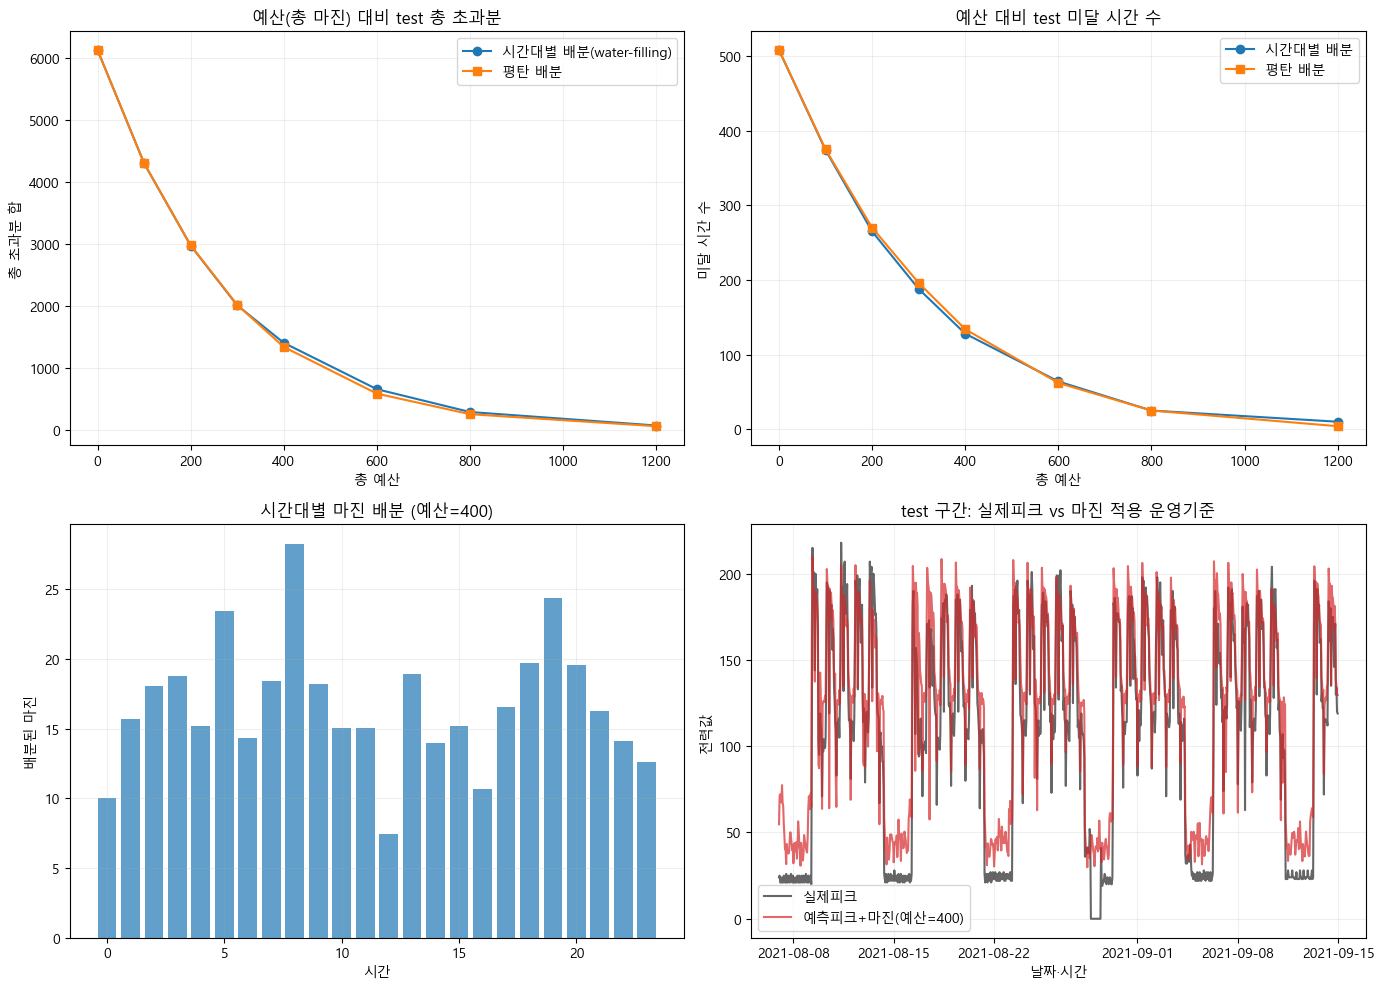

In [25]:
# ===== test 바깥 검증: 시간대별 배분 vs 평탄 배분 =====

test_hour = test_peak["시간"].to_numpy()
test_residual = test_peak["오차"].to_numpy(dtype=float)
n_test = len(test_peak)

comparison_rows = []

for budget in budget_candidates:
    margin_by_hour = allocation_results[budget]

    # (1) water-filling 배분: 시간대별로 다른 마진
    wf_margin_applied = margin_by_hour[test_hour]
    wf_shortfall = np.maximum(test_residual - wf_margin_applied, 0)
    wf_miss = int((wf_shortfall > 1e-9).sum())

    # (2) 평탄 배분: 같은 총 예산을 24시간에 균등 분배 (budget/24)
    flat_margin = budget / 24.0
    flat_shortfall = np.maximum(test_residual - flat_margin, 0)
    flat_miss = int((flat_shortfall > 1e-9).sum())

    comparison_rows.append({
        "예산": budget,
        "시간대별_총초과분": wf_shortfall.sum(),
        "시간대별_미달시간": wf_miss,
        "평탄_총초과분": flat_shortfall.sum(),
        "평탄_미달시간": flat_miss,
    })

comparison_table = pd.DataFrame(comparison_rows)
comparison_table["초과분_개선율(%)"] = np.where(
    comparison_table["평탄_총초과분"] > 0,
    (comparison_table["평탄_총초과분"] - comparison_table["시간대별_총초과분"])
    / comparison_table["평탄_총초과분"] * 100,
    0.0,
)

print("===== test 바깥 검증: 시간대별 배분 vs 평탄 배분 =====")
print(comparison_table.round(2).to_string(index=False))

print(
    f"\n전체 test 시간 수: {n_test:,}"
    "\n미달시간 = (예측피크 + 마진)에도 실제피크가 그 기준을 넘은 시간"
    "\n이 값들은 예산을 바꿀 때의 트레이드오프이며, 특정 예산이 '정답'이라는 뜻은 아닙니다."
)

# ----- 시각화 -----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ① 예산 대비 총 초과분 (Pareto)
axes[0, 0].plot(
    comparison_table["예산"], comparison_table["시간대별_총초과분"],
    marker="o", label="시간대별 배분(water-filling)",
)
axes[0, 0].plot(
    comparison_table["예산"], comparison_table["평탄_총초과분"],
    marker="s", label="평탄 배분",
)
axes[0, 0].set_title("예산(총 마진) 대비 test 총 초과분")
axes[0, 0].set_xlabel("총 예산")
axes[0, 0].set_ylabel("총 초과분 합")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.2)

# ② 예산 대비 미달 시간 수
axes[0, 1].plot(
    comparison_table["예산"], comparison_table["시간대별_미달시간"],
    marker="o", label="시간대별 배분",
)
axes[0, 1].plot(
    comparison_table["예산"], comparison_table["평탄_미달시간"],
    marker="s", label="평탄 배분",
)
axes[0, 1].set_title("예산 대비 test 미달 시간 수")
axes[0, 1].set_xlabel("총 예산")
axes[0, 1].set_ylabel("미달 시간 수")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.2)

# ③ 선택 예산(400)의 시간대별 마진 배분
example_margin = allocation_results[example_budget]
axes[1, 0].bar(HOURS, example_margin, color="tab:blue", alpha=0.7)
axes[1, 0].set_title(f"시간대별 마진 배분 (예산={example_budget})")
axes[1, 0].set_xlabel("시간")
axes[1, 0].set_ylabel("배분된 마진")
axes[1, 0].grid(alpha=0.2)

# ④ test 구간에서 실제피크 vs (예측피크+마진) 기준선
example_margin_applied = example_margin[test_hour]
axes[1, 1].plot(
    test_peak.index, test_peak["실제피크"],
    label="실제피크", color="black", alpha=0.6,
)
axes[1, 1].plot(
    test_peak.index, test_peak["예측피크"] + example_margin_applied,
    label=f"예측피크+마진(예산={example_budget})", color="tab:red", alpha=0.7,
)
axes[1, 1].set_title("test 구간: 실제피크 vs 마진 적용 운영기준")
axes[1, 1].set_xlabel("날짜·시간")
axes[1, 1].set_ylabel("전력값")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 6. 종합 결론
- 생산량·기온·습도가 비슷해도 피크가 크게 다르고, 시간대만으로도 위험 구분이 안 됨.
- 즉 **현재 데이터에 기록되지 않은 요인**(설비 운전방식, 중복가동, 계절적 기기전환 등)이 피크의 핵심 결정요인일 가능성이 높음.
- 유일하게 수치 개선을 보인 것은 1. 전력값 재분배지만, 생산계획과 무관한 전력값 자체 재배열이라 현실 적용성은 제한적임.
- 이는 분석의 실패가 아니라, **데이터 한계를 실험적으로 증명한 결과**로 포지셔닝 가능.